In [ ]:
# !git clone https://github.com/AInMicLab/deep-image-prior.git
# !mv deep-image-prior/* ./

In [14]:
import wandb

In [48]:
# !git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [41]:
!wandb init

Let's setup this directory for W&B!
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shriramgolla (shriramgolla-iit-hyderabad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Which project should we use?
wandb: (1) my-awesome-project
wandb: (2) Create New
wandb: Enter your choice: 2
wandb: You chose 'Create New'
Enter a name for your new project: SR_Dprior
wandb: Updated settings file /content/wandb/settings
This directory is configured!  Next, track a run:
* In your training script:
    import wandb
    wandb.init(project="sr_dprior")
* then `python <train.py>`.



In [42]:
from __future__ import print_function
import matplotlib.pyplot as plt
%matplotlib inline

import argparse
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import numpy as np
from models import *

import torch
import torch.optim

# from skimage.measure import compare_psnr
def compare_psnr(img1, img2):
    import math
    from skimage.metrics import peak_signal_noise_ratio as psnr
    return psnr(img1, img2)

from models.downsampler import Downsampler

from utils.sr_utils import *

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark =True
dtype = torch.cuda.FloatTensor

imsize = -1
factor = 4 # 8
enforse_div32 = 'CROP'
PLOT = True
path_to_image = '/content/Pokemon.jpg'

In [35]:
!wget -O Pokemon.jpg "https://eriktwice.com/wp-content/uploads/2019/01/Pokemon.Battle.Red_.3.Team_-1.jpg"

--2026-10-02 05:15:49--  https://eriktwice.com/wp-content/uploads/2019/01/Pokemon.Battle.Red_.3.Team_-1.jpg
Resolving eriktwice.com (eriktwice.com)... 213.158.84.64
Connecting to eriktwice.com (eriktwice.com)|213.158.84.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 115587 (113K) [image/jpeg]
Saving to: ‘Pokemon.jpg’

Pokemon.jpg         100%[===================>] 112.88K   569KB/s    in 0.2s    

2026-10-02 05:15:50 (569 KB/s) - ‘Pokemon.jpg’ saved [115587/115587]



In [37]:
fname = 'Pokemon.jpg'

HR and LR resolutions: (1056, 544), (264, 136)


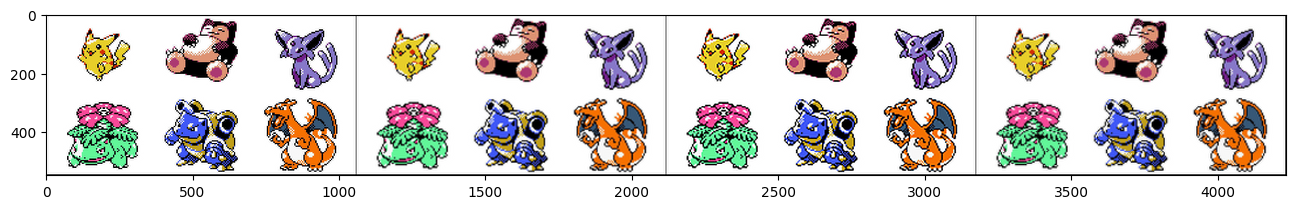

PSNR bicubic: 18.2291   PSNR nearest: 17.1061


In [43]:
# Starts here
imgs = load_LR_HR_imgs_sr(path_to_image , imsize, factor, enforse_div32)

imgs['bicubic_np'], imgs['sharp_np'], imgs['nearest_np'] = get_baselines(imgs['LR_pil'], imgs['HR_pil'])

if PLOT:
    plot_image_grid([imgs['HR_np'], imgs['bicubic_np'], imgs['sharp_np'], imgs['nearest_np']], 4,12);
    print ('PSNR bicubic: %.4f   PSNR nearest: %.4f' %  (
                                        compare_psnr(imgs['HR_np'], imgs['bicubic_np']),
                                        compare_psnr(imgs['HR_np'], imgs['nearest_np'])))

In [44]:
input_depth = 32

INPUT =     'noise'
pad   =     'reflection'
OPT_OVER =  'net'
KERNEL_TYPE='lanczos2'

LR = 0.01
tv_weight = 0.0

OPTIMIZER = 'adam'

if factor == 4:
    num_iter = 2000
    reg_noise_std = 0.03
elif factor == 8:
    num_iter = 4000
    reg_noise_std = 0.05

In [45]:
net_input = get_noise(input_depth, INPUT, (imgs['HR_pil'].size[1], imgs['HR_pil'].size[0])).type(dtype).detach()

NET_TYPE = 'skip' # UNet, ResNet
net = get_net(input_depth, 'skip', pad,
              skip_n33d=128,
              skip_n33u=128,
              skip_n11=4,
              num_scales=5,
              upsample_mode='bilinear').type(dtype)

# Losses
mse = torch.nn.MSELoss().type(dtype)

img_LR_var = np_to_torch(imgs['LR_np']).type(dtype)

downsampler = Downsampler(n_planes=3, factor=factor, kernel_type=KERNEL_TYPE, phase=0.5, preserve_size=True).type(dtype)

RuntimeError: Cannot initialize CUDA without ATen_cuda library. PyTorch splits its backend into two shared libraries: a CPU library and a CUDA library; this error has occurred because you are trying to use some CUDA functionality, but the CUDA library has not been loaded by the dynamic linker for some reason.  The CUDA library MUST be loaded, EVEN IF you don't directly use any symbols from the CUDA library! One common culprit is a lack of -Wl,--no-as-needed in your link arguments; many dynamic linkers will delete dynamic library dependencies if you don't depend on any of their symbols.  You can check if this has occurred by using ldd on your binary to see if there is a dependency on *_cuda.so library.

In [20]:
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="shriramgolla-iit-hyderabad",
    # Set the wandb project where this run will be logged.
    project="SR_Pokemon",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.02,
        "architecture": "DeepPrior",
        "dataset": "Pokemong.jpg",
        "epochs": 1,
    },
)

In [47]:
def closure():
    global i, net_input

    if reg_noise_std > 0:
        net_input = net_input_saved + (noise.normal_() * reg_noise_std)

    out_HR = net(net_input)
    out_LR = downsampler(out_HR)

    total_loss = mse(out_LR, img_LR_var)

    if tv_weight > 0:
        total_loss += tv_weight * tv_loss(out_HR)

    total_loss.backward()

    # Log
    psnr_LR = compare_psnr(imgs['LR_np'], torch_to_np(out_LR))
    psnr_HR = compare_psnr(imgs['HR_np'], torch_to_np(out_HR))
    print ('Iteration %05d    PSNR_LR %.3f   PSNR_HR %.3f' % (i, psnr_LR, psnr_HR), '\r', end='')

    run.log({"psnr_LR":psnr_LR, "psnr_HR":psnr_HR})

    # History
    psnr_history.append([psnr_LR, psnr_HR])

    if PLOT and i % 100 == 0:
        out_HR_np = torch_to_np(out_HR)
        plot_image_grid([imgs['HR_np'], imgs['bicubic_np'], np.clip(out_HR_np, 0, 1)], factor=13, nrow=3)

        run.log({"image": wandb.Image(np_to_pil(np.clip(out_HR_np, 0, 1)),caption = f"Image at {i} iter"  )})

    i += 1

    return total_loss

Starting optimization with ADAM


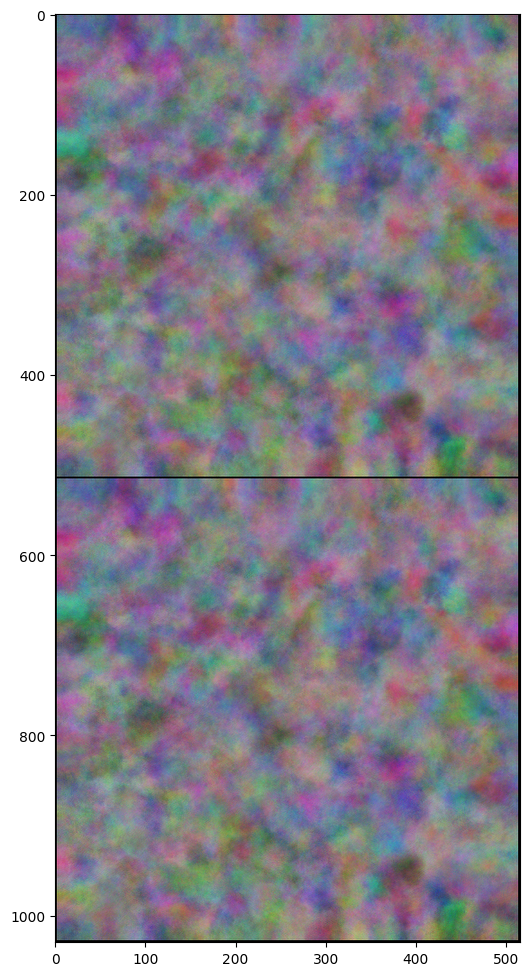

KeyboardInterrupt: 

In [21]:
psnr_history = []
net_input_saved = net_input.detach().clone()
noise = net_input.detach().clone()

i = 0
p = get_params(OPT_OVER, net, net_input)
optimize(OPTIMIZER, p, closure, LR, num_iter)